# Outlier Detection Subset Example
## Worked Example: Deschutes County Rx Event

This notebook demonstrates some of the outlier detection pipeline on a sample dataset
containing a single target neighbourhood (~40 devices). 

Two random seeds are compared to illustrate how each method (Info-Theory & ML).  

Data and parameters used here are not optimized according to the paper, nor is time averageing or consecutive hour duration being used. This should be considered a playground for a user to experiment with the methods in a reproducible fashion.

### Requirements
```
pip install elwood-spatial xgboost pandas numpy matplotlib seaborn scikit-learn
```

### Data
All example data is self-contained in the `data_subset/` directory:
- `deschutes_rx_event.parquet` — Hourly AQI for the target neighbourhood
- `network_7500m.json` / `network_12500m.json` — Spatial neighbour networks
- `xgboost_validation_7500.json` — Pretrained XGBoost model (17 features)
- `targets.json` — Target device ID and seeds to run

### Reference
```
Illson, S. (2026). elwood-spatial: Information-Theoretic Outlier Detection
for Spatial Networks (v0.1.1). Zenodo. https://doi.org/10.5281/zenodo.18856270
```

## 1. Configuration

The cell below loads the target device and seeds from `targets.json`, then sets up
detection parameters. The two seeds produce different perturbation windows on the
same target, allowing side-by-side comparison of detection performance.

- **`MODIFIED_AQI_BINS`** 12-bin AQI scheme introduced in the paper. A user may swap to `AQI_BINS` for standard 6-bin EPA AQI categories.

In [1]:
import pandas as pd
import numpy as np
import json
import math
import random
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

from elwood_spatial import (
    BinSpec, DetectionParams, PARAMS_OPERATIONAL,
    detect_outliers_batch, filter_network, get_neighbors,
    add_rolling_features, add_network_features, add_neighbor_deviation_features,
    shannon_entropy, information_content, bin_deviation,
    is_outlier as is_outlier_func,
)
from elwood_spatial.air_quality import AQI_BINS, AQI_MODIFIED_BINS

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

# ── Load target ────────────────────────────────────────────────────

DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data')

with open(os.path.join(DATA_DIR, 'targets.json')) as f:
    target_config = json.load(f)

TARGET_ID = target_config['target']
SEEDS = target_config['seeds']

# ── Detection parameters ─────────────────────────────

# AQI discretisation bins — choose one:
#   AQI_MODIFIED_BINS: 12 bins with transition zones at EPA AQI boundaries (default)
#   AQI_BINS:          6 bins matching standard EPA AQI categories
INPUT_AQI_BINS = AQI_MODIFIED_BINS   # swap this value to AQI_BINS for standard 6-bin scheme

PARAMS = DetectionParams(
    theta=1.75,           # information content threshold
    entropy_limit=1.75,   # maximum network entropy
    beta=3.5,             # bin deviation threshold = B/β
)

MIN_NEIGHBORS = 2

# ──────────────────────────────────────────────────────────────────────────────

print(f'Target:       {TARGET_ID}')
print(f'Seeds:        {SEEDS}')
print(f'Bins:         {INPUT_AQI_BINS.num_bins} categories')
print(f'Detection:    θ={PARAMS.theta}, S={PARAMS.entropy_limit}, β={PARAMS.beta}')
print(f'              bin deviation threshold = {INPUT_AQI_BINS.num_bins}/{PARAMS.beta} = {INPUT_AQI_BINS.num_bins / PARAMS.beta:.2f}')
print(f'Min neighbours: {MIN_NEIGHBORS}')

Target:       6761683684835711444
Seeds:        [14, 15]
Bins:         12 categories
Detection:    θ=1.75, S=1.75, β=3.5
              bin deviation threshold = 12/3.5 = 3.43
Min neighbours: 2


## 2. Load Event Data and Network

In [2]:
# Load event data
df = pd.read_parquet(os.path.join(DATA_DIR, 'deschutes_rx_event.parquet'))
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['id', 'timestamp']).reset_index(drop=True)

# Load networks
with open(os.path.join(DATA_DIR, 'network_7500m.json')) as f:
    network_7500 = json.load(f)
with open(os.path.join(DATA_DIR, 'network_12500m.json')) as f:
    network_12500 = json.load(f)

# Filter network to active devices
active_ids = set(df['id'].unique())
network_7500_active = filter_network(network_7500, active_ids, min_neighbors=MIN_NEIGHBORS)

neighbors = get_neighbors(network_7500_active, TARGET_ID)
relevant_ids = [TARGET_ID] + neighbors

print(f'Event: Deschutes Rx Subset')
print(f'  Rows: {len(df):,}')
print(f'  Devices: {df["id"].nunique()}')
print(f'  Date range: {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'  Target: {TARGET_ID} ({len(neighbors)} neighbours @7500m)')
print(f'  AQI range: {df["aqi"].min()} – {df["aqi"].max()}')
print()

# Show data structure
print('Data structure:')
df.head(8)

Event: Deschutes Rx Subset
  Rows: 3,799
  Devices: 41
  Date range: 2024-05-14 07:00:00 → 2024-05-18 06:00:00
  Target: 6761683684835711444 (14 neighbours @7500m)
  AQI range: 3 – 1028

Data structure:


,id,latitude,longitude,aqi,timestamp
0,-1366905986893162292,44.056347,-121.31722,22,2024-05-14 07:00:00
1,-1366905986893162292,44.056347,-121.31722,22,2024-05-14 08:00:00
2,-1366905986893162292,44.056347,-121.31722,21,2024-05-14 09:00:00
3,-1366905986893162292,44.056347,-121.31722,22,2024-05-14 10:00:00
4,-1366905986893162292,44.056347,-121.31722,23,2024-05-14 11:00:00
5,-1366905986893162292,44.056347,-121.31722,23,2024-05-14 12:00:00
6,-1366905986893162292,44.056347,-121.31722,22,2024-05-14 13:00:00
7,-1366905986893162292,44.056347,-121.31722,28,2024-05-14 14:00:00


## 3. Apply Synthetic Perturbations

We inject known sensor faults into selected devices to create ground truth for evaluation.
The paper (Section 2.5) defines five fault types that simulate common real-world sensor malfunctions:

| Type | Description | Effect |
|------|------------|--------|
| 1 | Fixed high value with intermittent dropout | Device becomes fixed at a high value, intermittently dropping out due to either failing QA/QC or electronic malfunction |
| 2 | Offline then low recovery | Device goes offline, then returns reporting a lower value — such as when an outdoor sensor is moved indoors |
| 3 | Stuck/flatline | Device becomes stuck and reports a single value without responding to ambient conditions |
| 4 | Amplification (75–100%) | Device measurement is amplified by a random factor increasing it to 75–100% of the original value |
| 5 | Erratic noise | Erratic and high-frequency noise is applied to the value |

A sixth type (control, no perturbation) is used during training but omitted here.
We demonstrate all five perturbation types on the same target device.

In [3]:
def perturb_with_noise(data, cycle_length=6, amplitude_scale=0.75, cut=None):
    """Apply sine wave oscillation to a subset of data."""
    data = np.array(data, dtype=float)
    if cut is None:
        cut = (0, len(data))
    start, end = cut
    data_range = np.nanmax(data[start:end]) - np.nanmin(data[start:end])
    if data_range == 0:
        data_range = 1
    frequency = len(data) / cycle_length
    x_cut = np.linspace(0, 2 * np.pi * frequency, end - start)
    perturbation = np.zeros_like(data)
    perturbation[start:end] = np.sin(x_cut) * (data_range * amplitude_scale)
    perturbed = data.copy()
    perturbed[start:end] += perturbation[start:end]
    return np.maximum(perturbed, 0)


def apply_perturbation(df_subset, unit_id, fault_type, measure='aqi'):
    """Apply a time-constrained perturbation to one device.
    
    Perturbation window: random 12-48 hour duration with 3-hour buffers
    at both ends to avoid edge effects.
    """
    df_subset = df_subset.copy()
    if 'perturb' not in df_subset.columns:
        df_subset['perturb'] = False
    df_subset['fault_type'] = 0

    unit_data = df_subset[df_subset['id'] == unit_id]
    timestamps = unit_data['timestamp'].sort_values().reset_index(drop=True)
    
    min_duration = 12
    min_required = 3 + min_duration + 3
    if len(timestamps) <= min_required:
        return df_subset

    # Random start (after 3h buffer) and duration (12-48h)
    start_idx = random.randint(3, len(timestamps) - 3 - min_duration)
    max_duration = min(48, len(timestamps) - start_idx - 3)
    duration = random.randint(min_duration, max_duration)
    end_idx = start_idx + duration

    start_time = timestamps.iloc[start_idx]
    end_time = timestamps.iloc[min(end_idx, len(timestamps) - 1)]

    perturb_mask = (
        (df_subset['id'] == unit_id) &
        (df_subset['timestamp'] >= start_time) &
        (df_subset['timestamp'] <= end_time)
    )

    if fault_type == 1:  # Fixed high value with intermittent dropout
        for idx in df_subset.index[perturb_mask]:
            if random.random() < 0.1:
                df_subset.at[idx, measure] = np.nan
            else:
                df_subset.at[idx, measure] = 500
    elif fault_type == 2:  # Offline then low recovery
        for idx in df_subset.index[perturb_mask]:
            row_time = df_subset.at[idx, 'timestamp']
            hours_since_start = (row_time - start_time).total_seconds() / 3600
            if hours_since_start <= 2:
                df_subset.at[idx, measure] = np.nan
            else:
                df_subset.at[idx, measure] = df_subset.at[idx, measure] * 0.1
    elif fault_type == 3:  # Stuck/flatline
        flatline_value = df_subset.loc[perturb_mask, measure].iloc[0]
        df_subset.loc[perturb_mask, measure] = flatline_value
    elif fault_type == 4:  # Amplification (75-100%)
        df_subset.loc[perturb_mask, measure] *= 1.5
    elif fault_type == 5:  # Erratic noise
        unit_mask = df_subset['id'] == unit_id
        values = df_subset.loc[unit_mask, measure].values
        noisy = perturb_with_noise(values, cycle_length=6, amplitude_scale=0.75,
                                   cut=(start_idx, end_idx))
        df_subset.loc[unit_mask, measure] = noisy

    df_subset.loc[perturb_mask, 'perturb'] = True
    df_subset.loc[perturb_mask, 'fault_type'] = fault_type

    return df_subset


# Fault type labels aligned with paper Section 2.5
FAULT_TYPES = {
    1: 'Fixed High / Dropout',
    2: 'Offline Recovery',
    3: 'Stuck/Flatline',
    4: 'Amplification',
    5: 'Erratic Noise',
}

print('Perturbation functions defined.')

Perturbation functions defined.


In [4]:
# Run perturbation for each seed
df_neighborhood = df[df['id'].isin(relevant_ids)].copy()
df_reference = df_neighborhood.copy()

# Build network subset for just this neighbourhood
network_subset = {rid: network_7500_active[rid] for rid in relevant_ids if rid in network_7500_active}

seed_results = {}  # seed → {df_faults, df_detected, df_feats, preds}

for seed in SEEDS:
    random.seed(seed)
    np.random.seed(seed)
    print(f'\n{"="*60}')
    print(f'SEED {seed}')
    print(f'{"="*60}')
    
    df_faults = {}
    for ft, label in FAULT_TYPES.items():
        df_faults[ft] = apply_perturbation(df_neighborhood.copy(), TARGET_ID, fault_type=ft)
        n = df_faults[ft]['perturb'].sum()
        print(f'  FT{ft} ({label}): {n} perturbed obs')
    
    seed_results[seed] = {'df_faults': df_faults}


SEED 14
  FT1 (Fixed High / Dropout): 46 perturbed obs
  FT2 (Offline Recovery): 30 perturbed obs
  FT3 (Stuck/Flatline): 20 perturbed obs
  FT4 (Amplification): 23 perturbed obs
  FT5 (Erratic Noise): 16 perturbed obs

SEED 15
  FT1 (Fixed High / Dropout): 13 perturbed obs
  FT2 (Offline Recovery): 27 perturbed obs
  FT3 (Stuck/Flatline): 35 perturbed obs
  FT4 (Amplification): 27 perturbed obs
  FT5 (Erratic Noise): 45 perturbed obs


## 4. Information-Theoretic Outlier Detection

The detection equation (Eq. 4 in the paper) flags a device as an outlier when **all three**
conditions hold simultaneously:

1. **Information content** ≥ θ (theta = 1.75): The device's reading is "surprising"
   relative to its neighbours
2. **Network entropy** ≤ S (entropy_limit = 1.75): Neighbours are in general agreement
   (low disorder)
3. **Bin deviation** ≥ B/β (12/3.5 ≈ 3.43): The device's bin index differs
   substantially from the neighbourhood mean

Not all perturbations produce *measurable outliers* — a perturbation must cause the
device to deviate enough from its neighbours to cross bin boundaries. Subtle faults
(e.g., small amplification during low-AQI periods) will not be detectable by any method. Additionally, true perturbations during periods of high network entropy will not be flagged. 

In [5]:
def run_detection(df_perturbed, network, target_id):
    """Run information-theoretic detection on a perturbed neighbourhood."""
    df_detect = df_perturbed[['id', 'timestamp', 'aqi']].dropna(subset=['aqi']).copy()
    df_detect = df_detect.rename(columns={'aqi': 'value'})
    result = detect_outliers_batch(df_detect, INPUT_AQI_BINS, network, PARAMS)
    result = result.rename(columns={'value': 'aqi'})
    df_out = df_perturbed.merge(
        result[['id', 'timestamp', 'is_outlier', 'information', 'entropy', 'bin_deviation']],
        on=['id', 'timestamp'], how='left', suffixes=('_orig', '')
    )
    for col in ['is_outlier', 'information', 'entropy', 'bin_deviation']:
        if f'{col}_orig' in df_out.columns:
            df_out.drop(columns=[f'{col}_orig'], inplace=True)
    df_out['is_outlier'] = df_out['is_outlier'].fillna(False)
    return df_out


for seed in SEEDS:
    r = seed_results[seed]
    print(f'\n--- Seed {seed} ---')
    r['df_detected'] = {}
    for ft, label in FAULT_TYPES.items():
        r['df_detected'][ft] = run_detection(r['df_faults'][ft], network_subset, TARGET_ID)
        target_rows = r['df_detected'][ft][r['df_detected'][ft]['id'] == TARGET_ID]
        tp = ((target_rows['perturb'] == True) & (target_rows['is_outlier'] == True)).sum()
        fn = ((target_rows['perturb'] == True) & (target_rows['is_outlier'] == False)).sum()
        fp = ((target_rows['perturb'] != True) & (target_rows['is_outlier'] == True)).sum()
        print(f'  FT{ft} ({label}): TP={tp}, FN={fn}, FP={fp}')


--- Seed 14 ---


  FT1 (Fixed High / Dropout): TP=31, FN=15, FP=0


  FT2 (Offline Recovery): TP=1, FN=29, FP=0


  FT3 (Stuck/Flatline): TP=0, FN=20, FP=0


  FT4 (Amplification): TP=0, FN=23, FP=0


...

  FT1 (Fixed High / Dropout): TP=7, FN=6, FP=0


  FT2 (Offline Recovery): TP=0, FN=27, FP=0


  FT3 (Stuck/Flatline): TP=16, FN=19, FP=0


  FT4 (Amplification): TP=0, FN=27, FP=0


  FT5 (Erratic Noise): TP=14, FN=31, FP=0


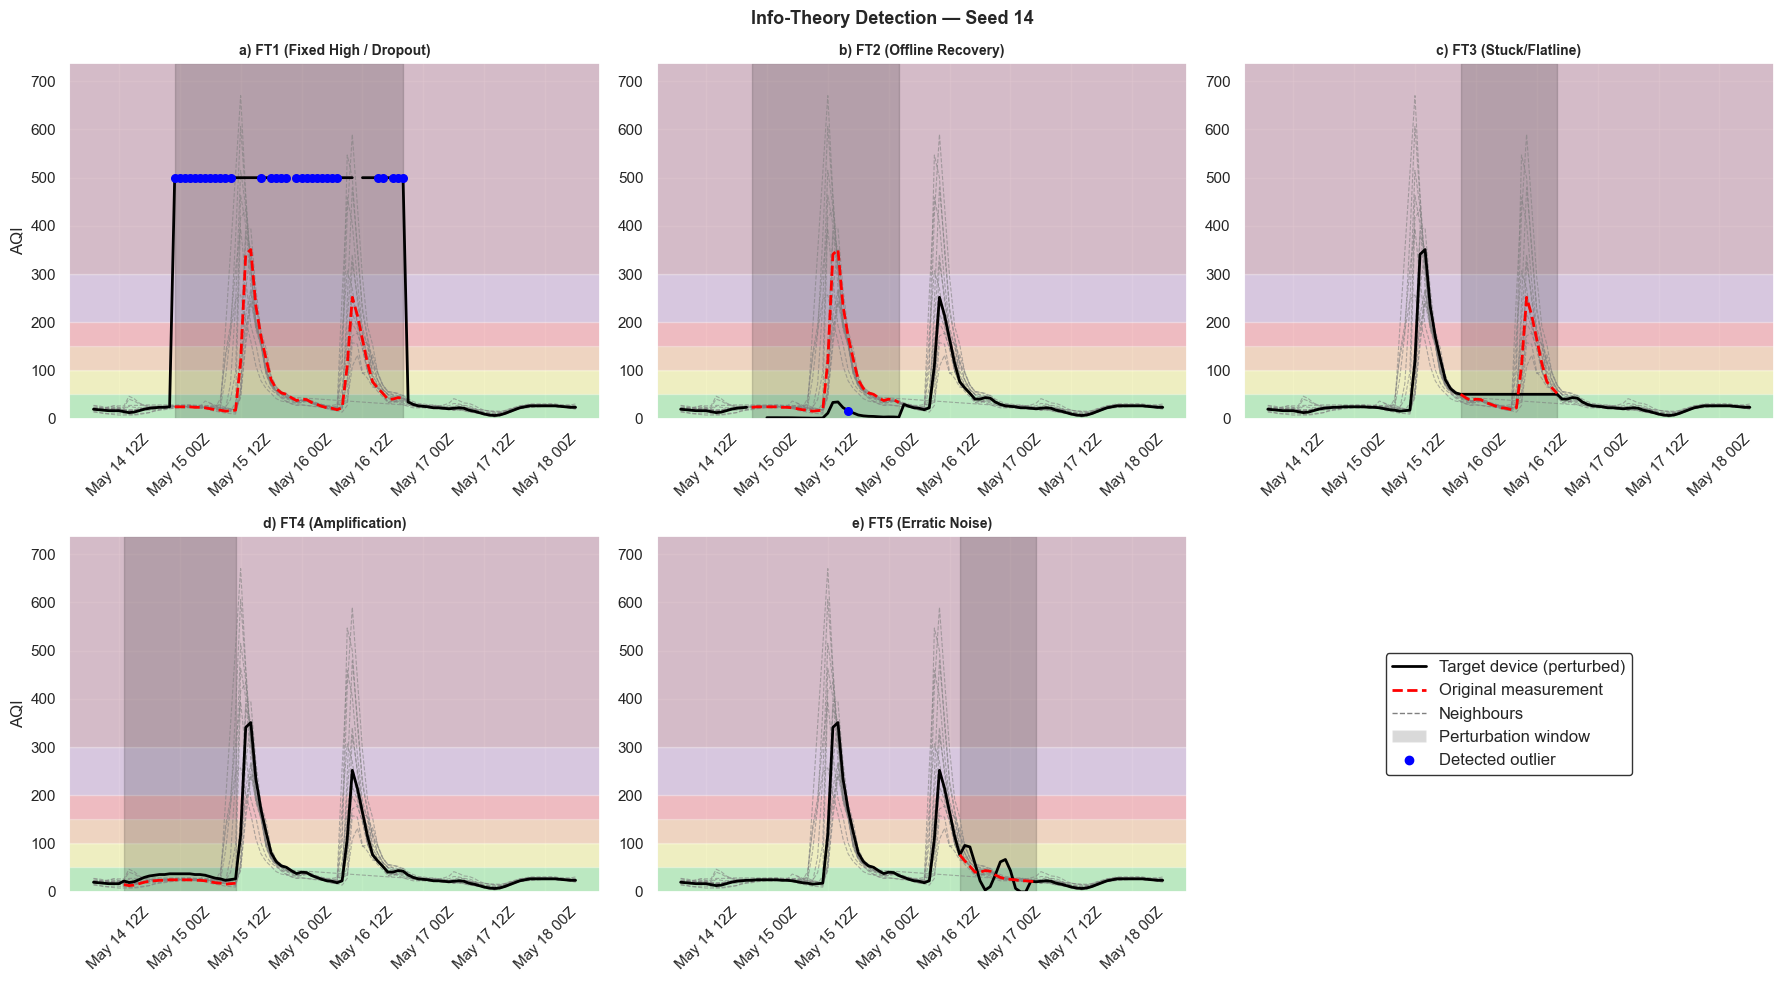

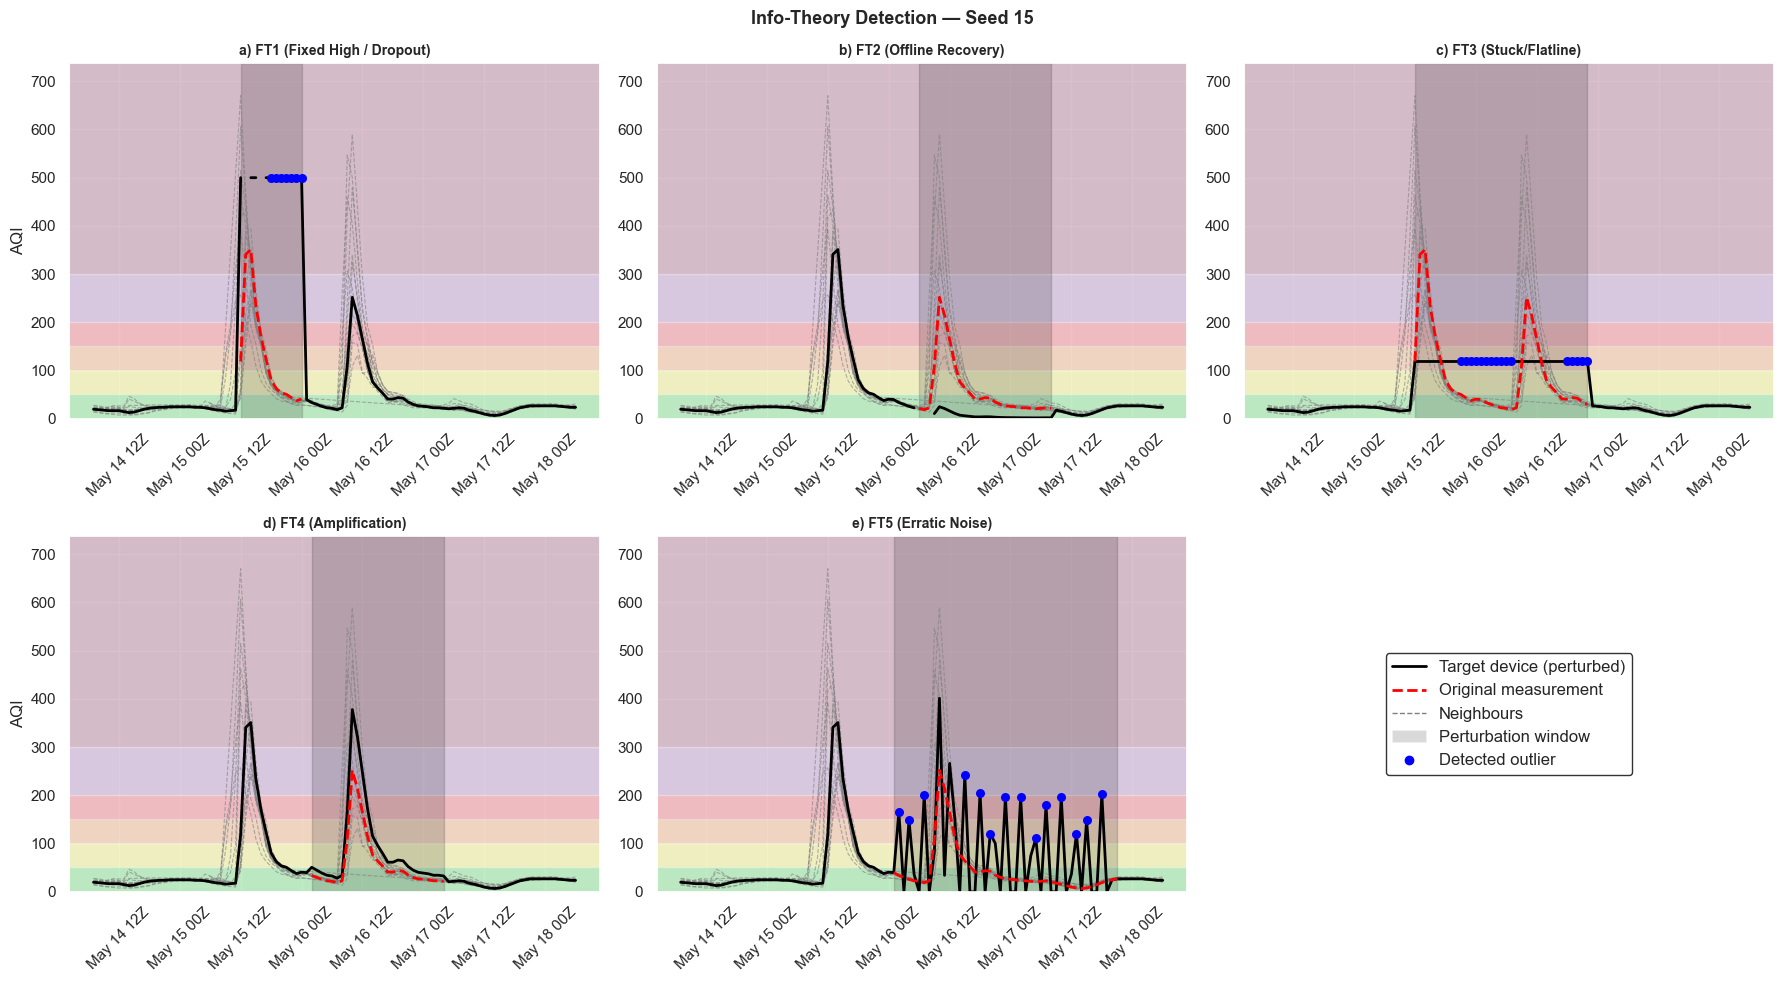

In [6]:
AQI_COLORS = [
    (0, 51, '#00E400'), (51, 101, '#FFFF00'), (101, 151, '#FF7E00'),
    (151, 201, '#FF0000'), (201, 301, '#8F3F97'), (301, 5000, '#7E0023'),
]

def plot_detection(df_result, target_id, df_ref, title, ax):
    for lo, hi, color in AQI_COLORS:
        ax.axhspan(lo, hi, facecolor=color, alpha=0.2)
    target = df_result[df_result['id'] == target_id]
    perturb_times = target.loc[target['perturb'] == True, 'timestamp']
    if not perturb_times.empty:
        ax.axvspan(perturb_times.min(), perturb_times.max(), color='black', alpha=0.15)
    for uid in df_result['id'].unique():
        if uid != target_id:
            sub = df_result[df_result['id'] == uid]
            ax.plot(sub['timestamp'], sub['aqi'], color='grey', lw=0.8, ls='--', alpha=0.6)
    ax.plot(target['timestamp'], target['aqi'], color='black', lw=2)
    if not perturb_times.empty:
        ref = df_ref[(df_ref['id'] == target_id) &
                     (df_ref['timestamp'] >= perturb_times.min()) &
                     (df_ref['timestamp'] <= perturb_times.max())]
        ax.plot(ref['timestamp'], ref['aqi'], color='red', lw=2, ls='--')
    outliers = target[target['is_outlier'] == True]
    ax.scatter(outliers['timestamp'], outliers['aqi'], color='blue', s=30, zorder=5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %HZ'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, max(df_result['aqi'].max() * 1.1, 60))
    ax.grid(True, alpha=0.3)

for seed in SEEDS:
    r = seed_results[seed]
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs_flat = axs.flatten()
    panel_labels = 'abcde'
    for i, (ft, label) in enumerate(FAULT_TYPES.items()):
        plot_detection(r['df_detected'][ft], TARGET_ID, df_reference,
                       f'{panel_labels[i]}) FT{ft} ({label})', axs_flat[i])
        if i % 3 == 0:
            axs_flat[i].set_ylabel('AQI')
    ax_leg = axs_flat[5]
    ax_leg.axis('off')
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Target device (perturbed)'),
        Line2D([0], [0], color='red', lw=2, ls='--', label='Original measurement'),
        Line2D([0], [0], color='grey', lw=1, ls='--', label='Neighbours'),
        Patch(facecolor='black', alpha=0.15, label='Perturbation window'),
        Line2D([0], [0], marker='o', color='blue', ls='None', ms=6, label='Detected outlier'),
    ]
    ax_leg.legend(handles=legend_elements, loc='center', frameon=True,
                  facecolor='white', edgecolor='black', fontsize=12)
    fig.suptitle(f'Info-Theory Detection — Seed {seed}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Feature Engineering for the ML Model

The XGBoost model uses 17 features combining information-theoretic metrics,
temporal statistics, and neighbour deviation features. These are computed using
the `elwood_spatial` library's feature engineering functions.

In [7]:
def engineer_features(df_perturbed, network_7500, network_12500, target_id):
    df_feat = df_perturbed.copy()
    df_feat = df_feat.rename(columns={'aqi': 'value'})
    df_feat = df_feat.dropna(subset=['value'])
    df_feat['log_aqi'] = np.log1p(df_feat['value'])
    df_feat['neighbor_count_7500'] = df_feat['id'].apply(
        lambda x: len(get_neighbors(network_7500, x)))
    df_feat['neighbor_count_12500'] = df_feat['id'].apply(
        lambda x: len(get_neighbors(network_12500, x)))
    df_feat = add_rolling_features(df_feat, windows=['3h', '6h'])
    df_feat = add_network_features(df_feat, network_7500, INPUT_AQI_BINS)
    df_feat = add_neighbor_deviation_features(
        df_feat, network_7500,
        feature_columns=['delta', 'directionality', 'range_3H', 'cv_3H', 'value']
    )
    df_feat['is_outlier'] = df_feat.apply(
        lambda row: int(is_outlier_func(
            row['information'], row['network_entropy'],
            row['bin_deviation'], INPUT_AQI_BINS.num_bins, PARAMS
        )), axis=1
    )
    df_feat = df_feat.rename(columns={
        'network_entropy': 'entropy_pct', 'information': 'information_pct',
        'cv_3H': 'cv_aqi_3h', 'cv_6H': 'cv_aqi_6h',
        'range_3H': 'range_aqi_3h', 'directionality': 'unit_directionality_3h',
        'std_3H': 'unit_entropy_3h', 'outage': 'num_outages_past_6h',
        'directionality_neighbor_dev': 'directionality_diff_from_neighbors_3h',
        'delta_neighbor_dev': 'delta_diff_from_neighbors_3h',
        'range_3H_neighbor_dev': 'range_diff_from_neighbors_3h',
        'cv_3H_neighbor_dev': 'entropy_diff_from_neighbors_3h',
        'value_neighbor_dev': 'aqi_diff_from_neighbors',
        'value': 'aqi',
    })
    return df_feat

MODEL_FEATURES = [
    'log_aqi', 'neighbor_count_7500', 'neighbor_count_12500',
    'entropy_pct', 'information_pct',
    'cv_aqi_3h', 'cv_aqi_6h', 'is_outlier',
    'range_aqi_3h', 'unit_directionality_3h', 'unit_entropy_3h',
    'num_outages_past_6h', 'directionality_diff_from_neighbors_3h',
    'delta_diff_from_neighbors_3h', 'range_diff_from_neighbors_3h',
    'entropy_diff_from_neighbors_3h', 'aqi_diff_from_neighbors'
]

for seed in SEEDS:
    r = seed_results[seed]
    r['df_feats'] = {}
    print(f'\n--- Seed {seed} ---')
    for ft, label in FAULT_TYPES.items():
        r['df_feats'][ft] = engineer_features(
            r['df_faults'][ft], network_7500_active, network_12500, TARGET_ID)
        print(f'  FT{ft}: {len(r["df_feats"][ft])} rows')


--- Seed 14 ---


  FT1: 1393 rows


  FT2: 1392 rows


  FT3: 1395 rows


  FT4: 1395 rows


...

  FT1: 1393 rows


  FT2: 1392 rows


  FT3: 1395 rows


  FT4: 1395 rows


  FT5: 1395 rows


## 6. Apply the Pretrained XGBoost Model

The pretrained validation XGBoost model (250 trees, max_depth=7) was trained on
perturbation experiments across all training events. It predicts the probability
that a given observation is a perturbed outlier based on the 17 features.

We apply it to all fault type experiments and compare with the information-theoretic
detection results.

In [8]:
model = xgb.Booster()
model.load_model(os.path.join(DATA_DIR, 'xgboost_validation_7500.json'))
print(f'Model: {model.num_boosted_rounds()} trees, {model.num_features()} features')

def predict_xgboost(df_feat, model, target_id):
    target_data = df_feat[df_feat['id'] == target_id].copy()
    X = target_data[MODEL_FEATURES].fillna(0).values
    dmat = xgb.DMatrix(X, feature_names=MODEL_FEATURES)
    probs = model.predict(dmat)
    target_data['xgb_prob'] = probs
    target_data['xgb_outlier'] = (probs >= 0.5).astype(int)
    return target_data

for seed in SEEDS:
    r = seed_results[seed]
    r['preds'] = {}
    print(f'\n--- Seed {seed} ---')
    for ft, label in FAULT_TYPES.items():
        r['preds'][ft] = predict_xgboost(r['df_feats'][ft], model, TARGET_ID)
        p = r['preds'][ft]
        print(f'  FT{ft} ({label}): XGB={p["xgb_outlier"].sum()}, '
              f'InfoTheory={p["is_outlier"].sum()}, Perturbed={p["perturb"].sum()}')

Model: 250 trees, 17 features

--- Seed 14 ---
  FT1 (Fixed High / Dropout): XGB=41, InfoTheory=31, Perturbed=44
  FT2 (Offline Recovery): XGB=9, InfoTheory=1, Perturbed=27
  FT3 (Stuck/Flatline): XGB=7, InfoTheory=0, Perturbed=20
  FT4 (Amplification): XGB=11, InfoTheory=0, Perturbed=23
  FT5 (Erratic Noise): XGB=15, InfoTheory=0, Perturbed=16

--- Seed 15 ---
  FT1 (Fixed High / Dropout): XGB=14, InfoTheory=7, Perturbed=11
  FT2 (Offline Recovery): XGB=2, InfoTheory=0, Perturbed=24
  FT3 (Stuck/Flatline): XGB=19, InfoTheory=16, Perturbed=35
  FT4 (Amplification): XGB=10, InfoTheory=0, Perturbed=27
  FT5 (Erratic Noise): XGB=39, InfoTheory=14, Perturbed=45


In [9]:
def evaluate_method(df_pred, method_col, label='Method'):
    y_true = df_pred['perturb'].fillna(False).astype(int)
    y_pred = df_pred[method_col].astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return {'Method': label, 'Precision': p, 'Recall': r, 'F1': f1,
            'TP': cm[1,1] if cm.shape[0]>1 else 0, 'FP': cm[0,1],
            'FN': cm[1,0] if cm.shape[0]>1 else 0}

for seed in SEEDS:
    r = seed_results[seed]
    results = []
    for ft, label in FAULT_TYPES.items():
        name = f'FT{ft} ({label})'
        results.append({**evaluate_method(r['preds'][ft], 'is_outlier', 'Info-Theory'), 'Experiment': name})
        results.append({**evaluate_method(r['preds'][ft], 'xgb_outlier', 'XGBoost'), 'Experiment': name})
    results_df = pd.DataFrame(results)[['Experiment', 'Method', 'Precision', 'Recall', 'F1', 'TP', 'FP', 'FN']]
    print(f'\n=== Seed {seed} ===')
    print(results_df.to_string(index=False))


=== Seed 14 ===
                Experiment      Method  Precision   Recall       F1  TP  FP  FN
FT1 (Fixed High / Dropout) Info-Theory   1.000000 0.704545 0.826667  31   0  13
FT1 (Fixed High / Dropout)     XGBoost   0.951220 0.886364 0.917647  39   2   5
    FT2 (Offline Recovery) Info-Theory   1.000000 0.037037 0.071429   1   0  26
    FT2 (Offline Recovery)     XGBoost   0.333333 0.111111 0.166667   3   6  24
      FT3 (Stuck/Flatline) Info-Theory   0.000000 0.000000 0.000000   0   0  20
      FT3 (Stuck/Flatline)     XGBoost   0.571429 0.200000 0.296296   4   3  16
       FT4 (Amplification) Info-Theory   0.000000 0.000000 0.000000   0   0  23
       FT4 (Amplification)     XGBoost   0.454545 0.217391 0.294118   5   6  18
       FT5 (Erratic Noise) Info-Theory   0.000000 0.000000 0.000000   0   0  16
       FT5 (Erratic Noise)     XGBoost   0.800000 0.750000 0.774194  12   3   4



=== Seed 15 ===
                Experiment      Method  Precision   Recall       F1  TP  FP  FN
FT1 (Fixed High / Dropout) Info-Theory   1.000000 0.636364 0.777778   7   0   4
FT1 (Fixed High / Dropout)     XGBoost   0.571429 0.727273 0.640000   8   6   3
    FT2 (Offline Recovery) Info-Theory   0.000000 0.000000 0.000000   0   0  24
    FT2 (Offline Recovery)     XGBoost   0.000000 0.000000 0.000000   0   2  24
      FT3 (Stuck/Flatline) Info-Theory   1.000000 0.457143 0.627451  16   0  19
      FT3 (Stuck/Flatline)     XGBoost   0.894737 0.485714 0.629630  17   2  18
       FT4 (Amplification) Info-Theory   0.000000 0.000000 0.000000   0   0  27
       FT4 (Amplification)     XGBoost   0.800000 0.296296 0.432432   8   2  19
       FT5 (Erratic Noise) Info-Theory   1.000000 0.311111 0.474576  14   0  31
       FT5 (Erratic Noise)     XGBoost   0.948718 0.822222 0.880952  37   2   8


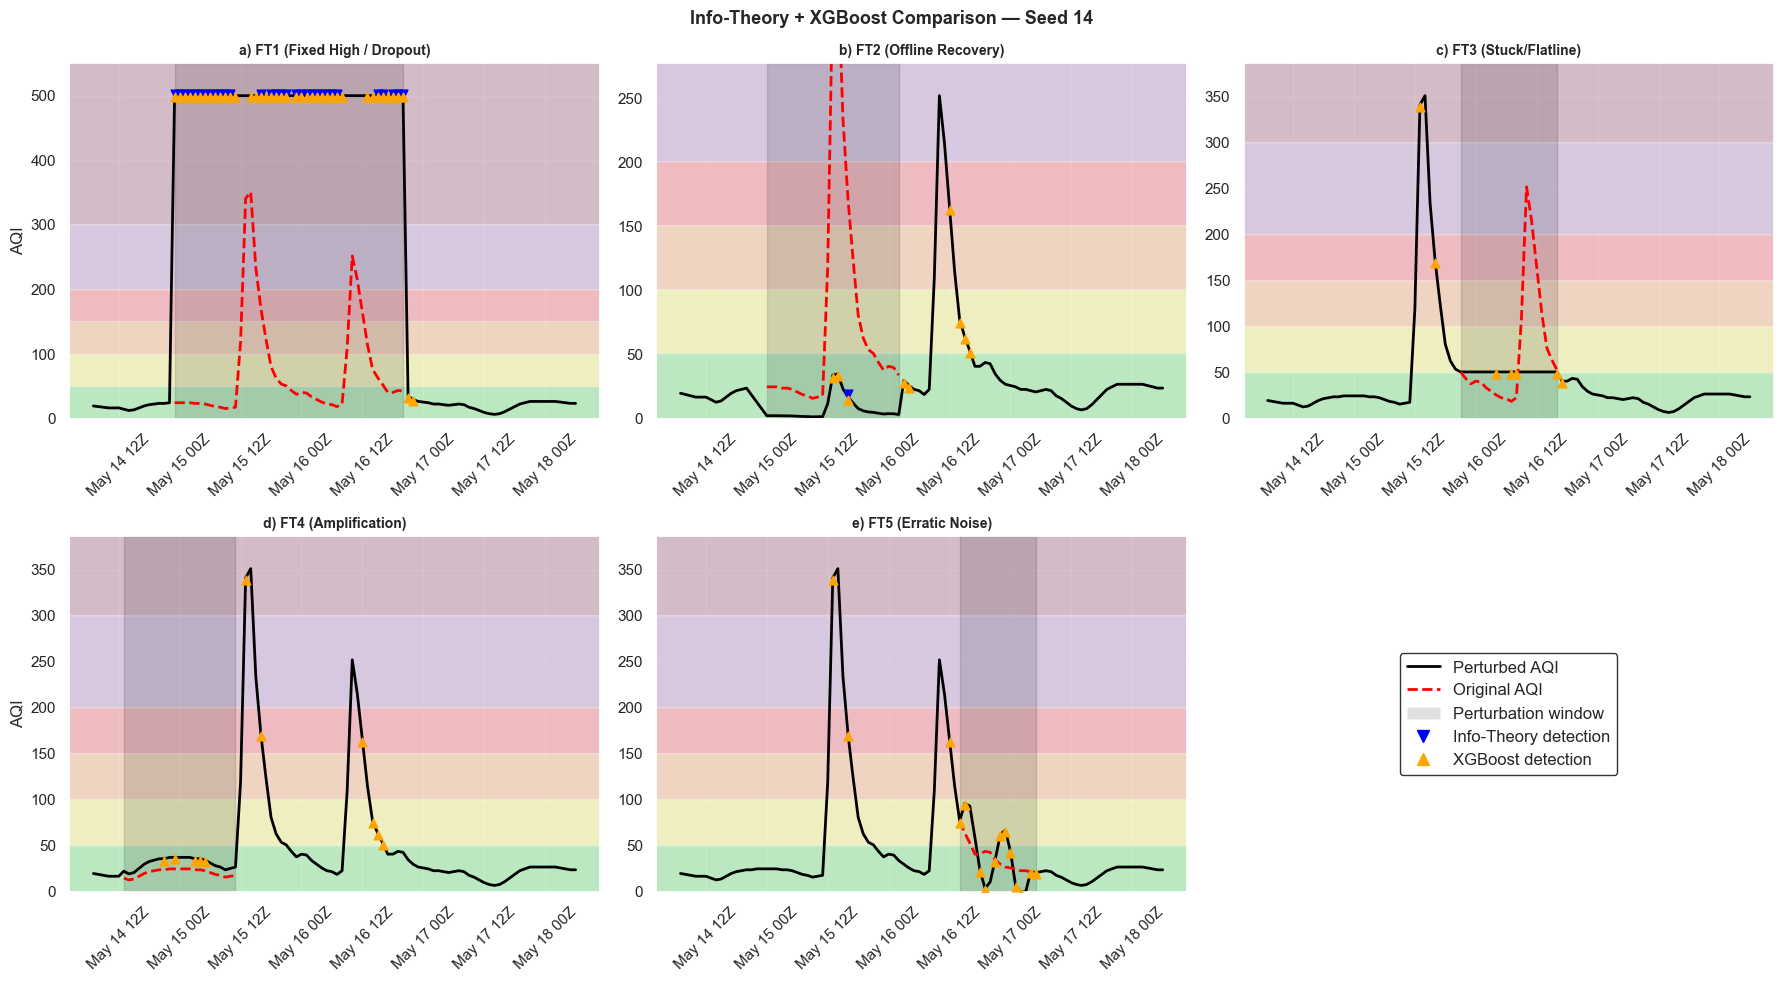

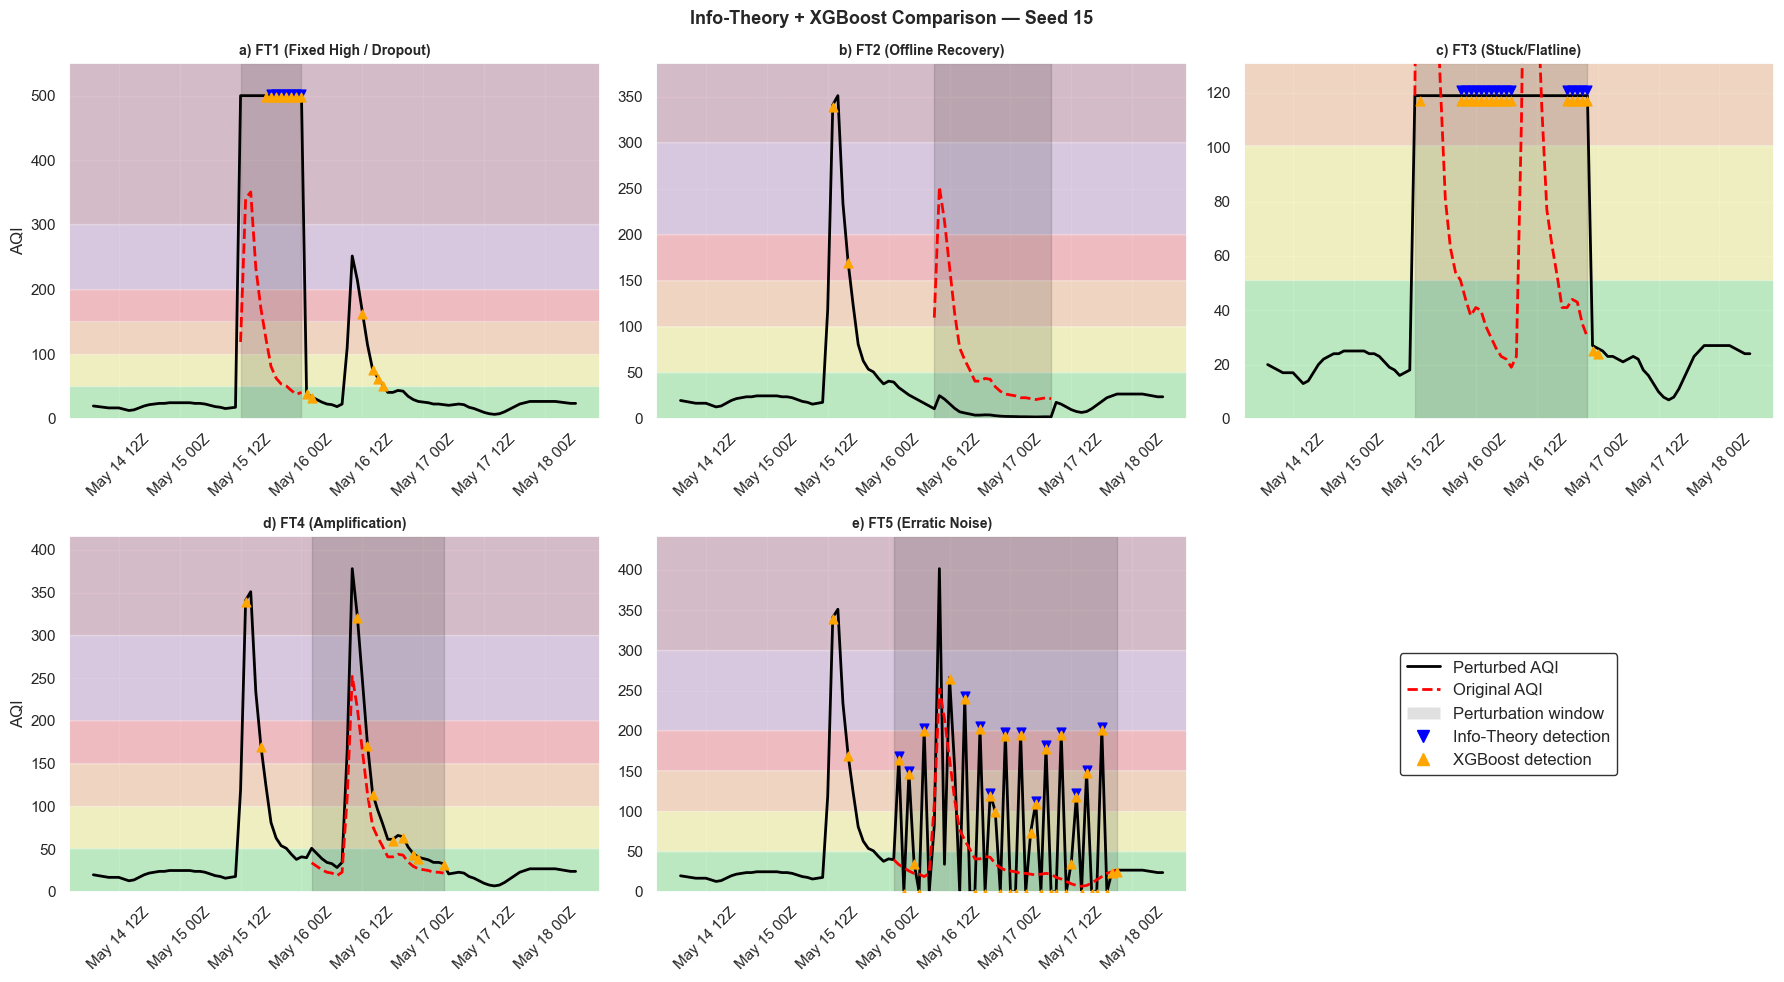

In [10]:
def plot_comparison(pred_df, target_id, df_ref, title, ax):
    for lo, hi, color in AQI_COLORS:
        ax.axhspan(lo, hi, facecolor=color, alpha=0.2)
    perturb_times = pred_df.loc[pred_df['perturb'] == True, 'timestamp']
    if not perturb_times.empty:
        ax.axvspan(perturb_times.min(), perturb_times.max(), color='black', alpha=0.12)
    ax.plot(pred_df['timestamp'], pred_df['aqi'], color='black', lw=2)
    if not perturb_times.empty:
        ref = df_ref[(df_ref['id'] == target_id) &
                     (df_ref['timestamp'] >= perturb_times.min()) &
                     (df_ref['timestamp'] <= perturb_times.max())]
        ax.plot(ref['timestamp'], ref['aqi'], color='red', lw=2, ls='--')
    it_det = pred_df[pred_df['is_outlier'] == 1]
    ax.scatter(it_det['timestamp'], it_det['aqi'] + 2,
               color='blue', s=40, marker='v', zorder=5)
    xgb_det = pred_df[pred_df['xgb_outlier'] == 1]
    ax.scatter(xgb_det['timestamp'], xgb_det['aqi'] - 2,
               color='orange', s=40, marker='^', zorder=5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %HZ'))
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, max(pred_df['aqi'].max() * 1.1, 60))
    ax.grid(True, alpha=0.3)

for seed in SEEDS:
    r = seed_results[seed]
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    axs_flat = axs.flatten()
    panel_labels = 'abcde'
    for i, (ft, label) in enumerate(FAULT_TYPES.items()):
        plot_comparison(r['preds'][ft], TARGET_ID, df_reference,
                        f'{panel_labels[i]}) FT{ft} ({label})', axs_flat[i])
        if i % 3 == 0:
            axs_flat[i].set_ylabel('AQI')
    ax_leg = axs_flat[5]
    ax_leg.axis('off')
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Perturbed AQI'),
        Line2D([0], [0], color='red', lw=2, ls='--', label='Original AQI'),
        Patch(facecolor='black', alpha=0.12, label='Perturbation window'),
        Line2D([0], [0], marker='v', color='blue', ls='None', ms=8, label='Info-Theory detection'),
        Line2D([0], [0], marker='^', color='orange', ls='None', ms=8, label='XGBoost detection'),
    ]
    ax_leg.legend(handles=legend_elements, loc='center', frameon=True,
                  facecolor='white', edgecolor='black', fontsize=12)
    fig.suptitle(f'Info-Theory + XGBoost Comparison — Seed {seed}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()